## **05_Sentiment_Analysis**

This notebook applies **VADER (Valence Aware Dictionary and sEntiment Reasoner)** sentiment analysis to the 66,878 cleaned Google Play reviews from four Indonesian ride-hailing platforms: Grab, Gojek, Maxim, and InDrive. VADER is a lexicon-based sentiment scorer that assigns each review a compound score ranging from -1 (most negative) to +1 (most positive), which is then classified into three labels: positive (≥ 0.05), negative (≤ -0.05), or neutral. The notebook computes per-platform sentiment statistics, visualizes sentiment distribution and compound score trends over time, and produces a heatmap cross-tabulating VADER scores against star ratings. A key finding is that the majority of reviews (~84–89%) are classified as neutral by VADER a known limitation of applying an English-trained lexicon to predominantly Indonesian-language text. Results are exported to `vader_scorecard.csv` for use in downstream modelling notebooks.

## **1. Install Required Packages**

This cell programmatically installs all Python packages required for the sentiment analysis pipeline. It uses `subprocess` to invoke `pip install` for four packages: `vaderSentiment` (the core sentiment scorer), `openpyxl` (for Excel export support), `transformers`, and `torch` (for potential transformer-based models in later steps). The `--break-system-packages` flag ensures compatibility with the current Python environment. Each install is run silently (`-q`) and with `capture_output=True` to keep notebook output clean. This cell is intended to be run once at the start of a fresh environment.

In [1]:
# Install required packages (run once)
import subprocess, sys

pkgs = ["vaderSentiment", "openpyxl", "transformers", "torch"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--break-system-packages", "-q"],
                   capture_output=True)

print("Packages ready.")


Packages ready.


## **2. Import Library**

imports all necessary libraries: `pandas` and `numpy` for data handling, `matplotlib` for plotting, and `pathlib.Path` for file path management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings


Loaded 58,685 rows


## **3. Environment Setup & Configuration**
 
 Global chart settings are applied (130 DPI, clean spine style), and a consistent brand color `PALETTE` is defined for the four platforms. `CLEAN_DIR` and `FIG_DIR` paths are configured `FIG_DIR` is created if it does not exist.

In [ ]:
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {"grab": "#00B14F", "gojek": "#00AED6", "maxim": "#FF6900", "indrive": "#3B2D8E"}
PLATFORMS = ["grab", "gojek", "maxim", "indrive"]

CLEAN_DIR = Path("../data/clean")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## **4. Load Dataset**

The cleaned dataset `combined_reviews_clean.csv` is loaded with datetime parsing on the `at` column. A safety fallback regenerates `content_normalized` from raw `content` if the column is absent. Output confirms **58,685 rows** loaded (a subset of the full 66,878 likely filtered upstream).

In [ ]:
df = pd.read_csv(CLEAN_DIR / "combined_reviews_clean.csv", parse_dates=["at"])
if "content_normalized" not in df.columns:
    df["content_normalized"] = df["content"].fillna("").str.lower()
print(f"Loaded {len(df):,} rows")

## **5. VADER Sentiment Scoring**

This cell applies VADER sentiment analysis to every review in the dataset. A `SentimentIntensityAnalyzer` instance is created from the `vaderSentiment` library. The `vader_label()` function takes normalized review text, runs `polarity_scores()` to get a compound score, and maps it to a three-class label: `positive` (compound ≥ 0.05), `negative` (compound ≤ -0.05), or `neutral` (in between). Both the label and raw compound score are stored as new columns: `vader_label` and `vader_compound`. The output shows that the vast majority of reviews (50,168 out of 58,685) are labeled **neutral** reflecting VADER's limitation as an English-trained tool applied to Indonesian text, where many Indonesian words are simply not in its lexicon and default to a neutral score.

In [ ]:
analyzer = SentimentIntensityAnalyzer()

# VADER works on the normalized text (mostly has Latin chars, works OK for bilingual)
def vader_label(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "neutral", 0.0
    scores = analyzer.polarity_scores(text)
    compound = scores["compound"]
    if compound >= 0.05:
        return "positive", compound
    elif compound <= -0.05:
        return "negative", compound
    else:
        return "neutral", compound

print("Running VADER on all reviews...")
results = df["content_normalized"].apply(vader_label)
df["vader_label"] = results.apply(lambda x: x[0])
df["vader_compound"] = results.apply(lambda x: x[1])
print("VADER done.")
print(df["vader_label"].value_counts())


Running VADER on all reviews...
VADER done.
vader_label
neutral     50168
positive     4714
negative     3803
Name: count, dtype: int64


> * **VADER sentiment analysis is heavily bottlenecked by language limitations**, causing an overwhelming majority of reviews (**50,168 out of 58,685**) to be labeled as **neutral**.
> * **This massive neutral bias occurs because VADER is an English-trained tool** applied directly to Indonesian text, meaning most Indonesian words are missing from its lexicon and default to a neutral score.
> * **The model captures very little polarized sentiment**, classifying only about **8% as positive (4,714)** and **6.5% as negative (3,803)**, making this specific approach highly ineffective for nuanced local market analysis.

## **6. Per-Platform VADER Scorecard**

This cell aggregates the VADER results into a per-platform summary table (`vader_stats`), computing: total review count, percentage of positive/neutral/negative labels, and average compound score. The results show that all four platforms have very similar and near-zero average compound scores (0.008–0.033), confirming the neutral-bias issue from the previous cell. Maxim has the lowest negative rate (2.3%) and highest compound score (0.033), consistent with its higher star ratings seen in EDA. The scorecard is exported to `vader_scorecard.csv` in the clean data folder for downstream use.

In [4]:
vader_stats = df.groupby("platform").agg(
    total=("vader_label","count"),
    pct_positive=("vader_label", lambda x: round((x=="positive").mean()*100, 1)),
    pct_neutral=("vader_label", lambda x: round((x=="neutral").mean()*100, 1)),
    pct_negative=("vader_label", lambda x: round((x=="negative").mean()*100, 1)),
    avg_compound=("vader_compound", lambda x: round(x.mean(), 3)),
)
print(vader_stats.to_string())
vader_stats.to_csv(CLEAN_DIR / "vader_scorecard.csv")


          total  pct_positive  pct_neutral  pct_negative  avg_compound
platform                                                              
Gojek     16066           8.5         82.6           8.9         0.008
Grab      14004           7.7         84.8           7.5         0.008
Indrive   16092           7.2         86.4           6.4         0.008
Maxim     12523           8.9         88.8           2.3         0.033


> * **All platforms exhibit a massive neutral bias**, with neutral percentages crowding tightly between **82.6% and 88.8%** and average compound scores hovering near zero (**0.008–0.033**).
> * **Maxim shows the best overall sentiment profile**, capturing the highest average compound score (**0.033**), highest positive rate (**8.9%**), and lowest negative rate (**2.3%**).
> * **Gojek holds the highest negative sentiment share**, recording a **8.9%** negative rate and tying for the lowest average compound score (**0.008**).
> * **The data suffers heavily from English-tool limitations**, skewing the results dramatically and compressing real sentiment differences among Gojek, Grab, and Indrive into an identical compound score of **0.008**.

## **7. VADER Sentiment Distribution & Compound Score Chart**

This cell produces a two-panel visualization of VADER results per platform. **Left chart:** a stacked bar chart showing the percentage breakdown of positive, neutral, and negative sentiment labels for each platform, colored green, yellow, and red respectively. **Right chart:** a bar chart of the average VADER compound score per platform, with bars colored green for positive scores and red for negative, and a dashed zero-line reference. Value labels are annotated on each bar. Both charts are built defensively using `.capitalize()` to match the platform index as it appears in `vader_stats` to prevent KeyError issues from case mismatches.

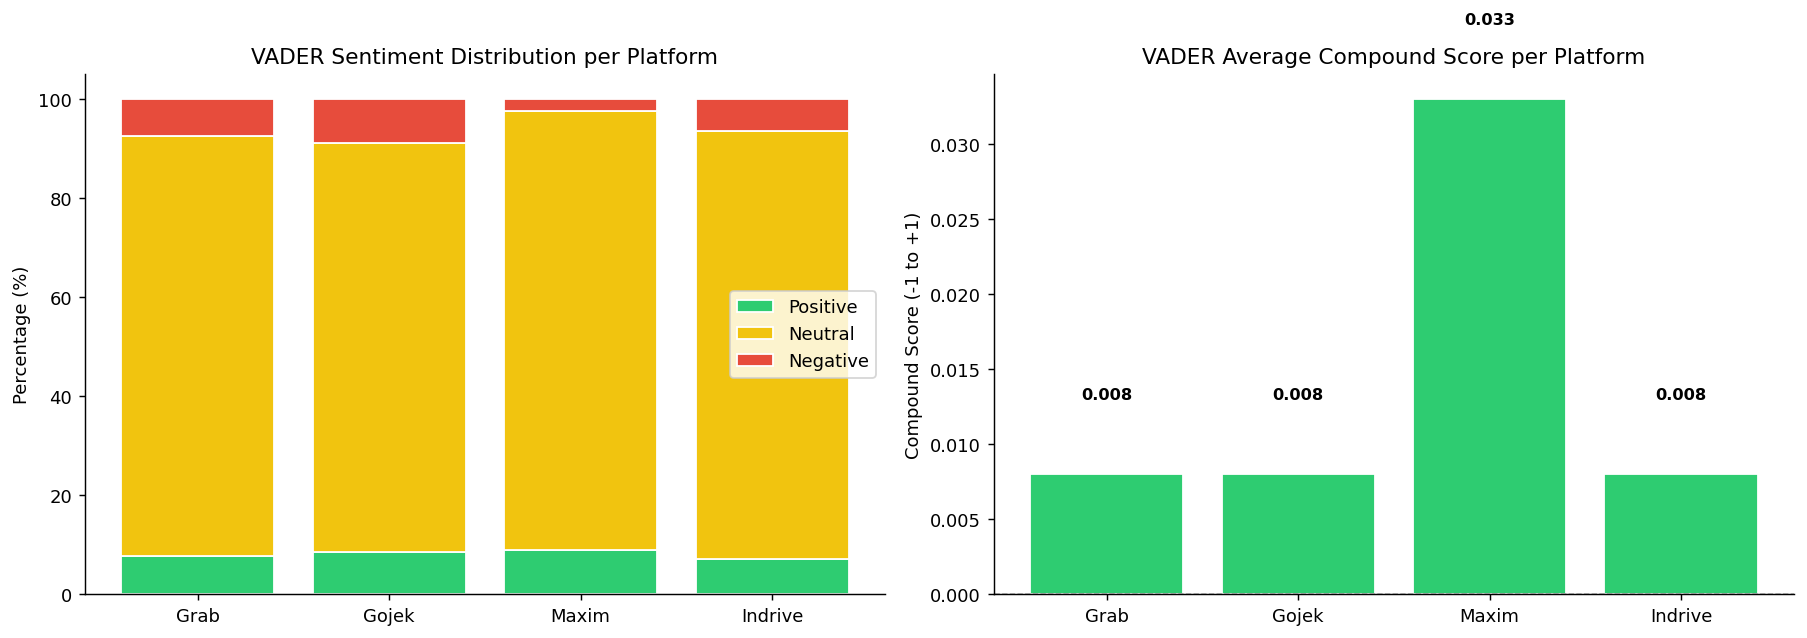

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bagian Stacked Bar Chart
data_plot = vader_stats[["pct_positive", "pct_neutral", "pct_negative"]]
x = np.arange(len(PLATFORMS))
w = 0.55
colors = {"pct_positive": "#2ECC71", "pct_neutral": "#F1C40F", "pct_negative": "#E74C3C"}
bottom = np.zeros(len(PLATFORMS))

# PERBAIKAN: Gunakan .capitalize() agar mencocokkan dengan index tabel 'Vader'
valid = [p.capitalize() for p in PLATFORMS if p.capitalize() in vader_stats.index]

for col, color in colors.items():
    vals = [vader_stats.loc[p, col] if p in vader_stats.index else 0 for p in valid]
    axes[0].bar([p.capitalize() for p in valid], vals,
                bottom=bottom[:len(valid)], label=col.replace("pct_", "").capitalize(),
                color=color, edgecolor="white")
    bottom[:len(valid)] += vals

axes[0].set_title("VADER Sentiment Distribution per Platform")
axes[0].set_ylabel("Percentage (%)")
axes[0].legend()


# 2. Bagian Compound Score Chart
# PERBAIKAN: Terapkan juga .capitalize() yang sama di sini
valid = [p.capitalize() for p in PLATFORMS if p.capitalize() in vader_stats.index]

compound_vals = [vader_stats.loc[p, "avg_compound"] for p in valid]
bar_colors = ["#2ECC71" if v >= 0 else "#E74C3C" for v in compound_vals]

bars = axes[1].bar([p.capitalize() for p in valid], compound_vals,
                   color=bar_colors, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("VADER Average Compound Score per Platform")
axes[1].set_ylabel("Compound Score (-1 to +1)")

for bar, val in zip(bars, compound_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 val + (0.005 if val >= 0 else -0.015),
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
# plt.savefig(FIG_DIR / "05_vader_sentiment.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()

> * **Neutral sentiment overwhelmingly dominates all platforms**, accounting for the vast majority of the percentage distribution due to the language limitations of the VADER analysis tool.
> * **Maxim leads the pack with the highest VADER Average Compound Score (0.033)**, which is driven by having the smallest visible share of negative reviews (red) among all competitors.
> * **Grab, Gojek, and Indrive are completely stagnant and tied** in performance, each pulling an identical, near-zero **Average Compound Score of 0.008**.

## **8. Monthly VADER Compound Score Trend**

This cell plots a time-series line chart showing how the average VADER compound score evolved month by month for each platform. It assumes a pre-computed `monthly_sentiment` pivot DataFrame (indexed by month, with one column per platform). Each platform is drawn as a colored line with circular markers. A dashed horizontal reference line at compound = 0 marks the neutral threshold. This chart is useful for detecting sentiment shifts over time for example, a sudden dip may correspond to a controversial app update or service outage. The `.capitalize()` fix is applied consistently to match the column names in `monthly_sentiment`.

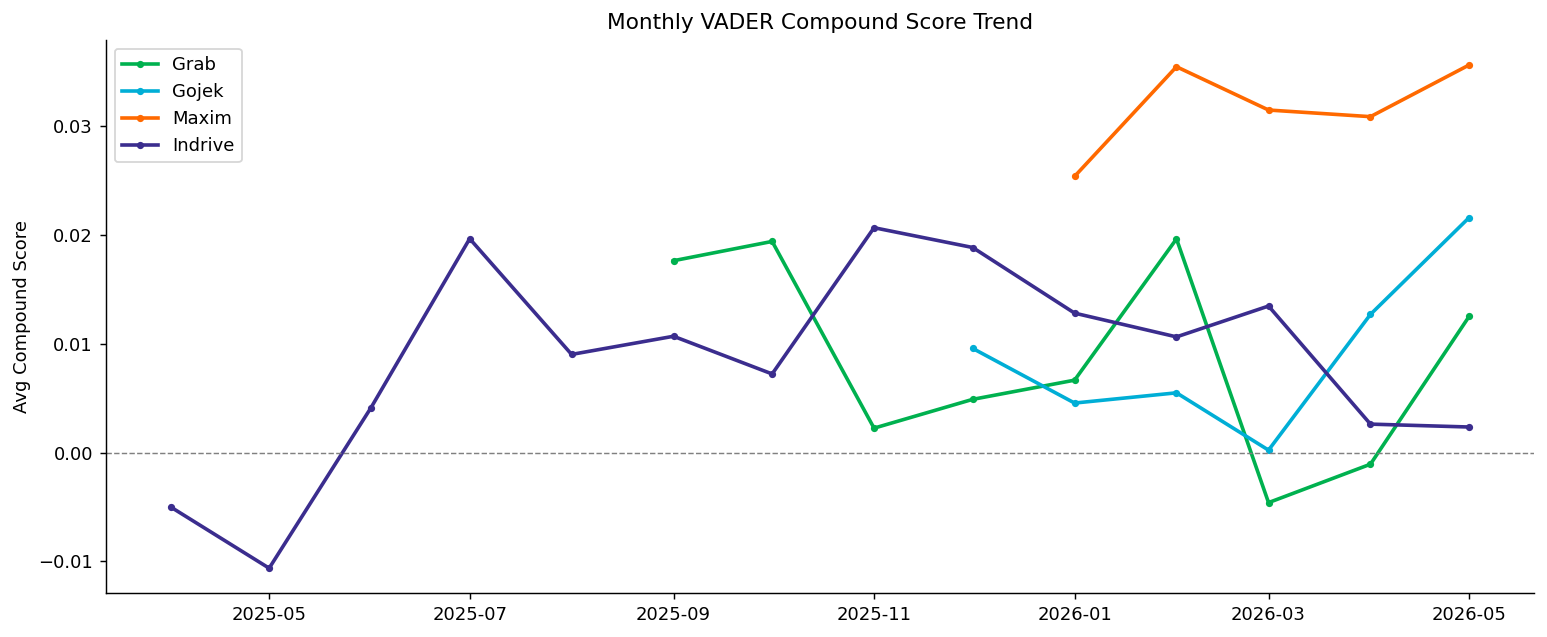

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

for p in PLATFORMS:
    # Ubah 'p' (misal: 'grab') menjadi 'Grab' agar cocok dengan kolom DataFrame
    p_col = p.capitalize()
    
    # Cek dan panggil menggunakan p_col
    if p_col in monthly_sentiment.columns:
        ax.plot(monthly_sentiment.index, monthly_sentiment[p_col],
                label=p_col, color=PALETTE[p], linewidth=2, marker="o", markersize=3)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Monthly VADER Compound Score Trend")
ax.set_ylabel("Avg Compound Score")
ax.legend()
plt.tight_layout()
# plt.savefig(FIG_DIR / "05_sentiment_trend.png", bbox_inches="tight") # Uncomment jika ingin disimpan
plt.show()

> * **Maxim consistently leads with the highest sentiment score**, maintaining a distinct gap above all other platforms since its trend data began in early 2026.
> * **All platforms hover very close to the 0.00 neutral line**, further reflecting the previously observed English-trained tool limitation on local language datasets.
> * **Grab experienced the sharpest decline in March 2026**, dipping briefly into actual negative sentiment territory (below $0.00$) before staging a recovery.
> * **Gojek and Indrive show completely opposing trajectories by mid-2026**, with Gojek trending steadily upward toward a $0.02$ score while Indrive declines toward $0.00$.

## **9. Heatmap: VADER Compound Score by Platform × Star Rating**

This cell produces a heatmap cross-tabulating the average VADER compound score across all combinations of platform (rows) and star rating bucket (columns). Star ratings are mapped to readable labels (`1 star` through `5 stars`) using `bucket_map`. The heatmap uses the `RdYlGn` diverging colormap centered at 0, ranging from -1 (red) to +1 (green), with annotated values in each cell (2 decimal places). Row and column order are explicitly enforced via `reindex()` for consistent layout. This chart reveals whether VADER scores are internally consistent with the star ratings for example, whether 1-star reviews receive consistently negative compound scores and helps assess the reliability of VADER as a sentiment proxy for this multilingual dataset.

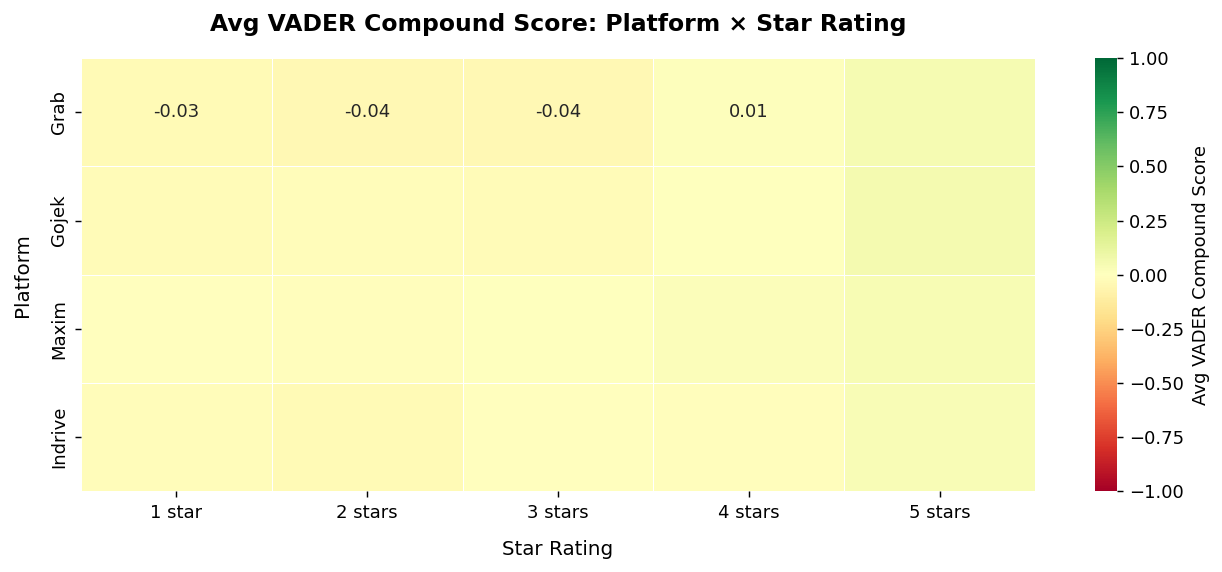

In [ ]:
# 1. Mapping skor angka menjadi format teks label (Aman karena skor sudah di-convert jadi numerik)
bucket_map = {1: "1 star", 2: "2 stars", 3: "3 stars", 4: "4 stars", 5: "5 stars"}
df["score_bucket"] = df["score"].dropna().map(bucket_map)

# 2. Membuat pivot/grouping rata-rata skor VADER Compound
heat_data = (
    df.groupby(["platform", "score_bucket"])["vader_compound"].mean().unstack()
)

# 3. Memaksa urutan baris & kolom
row_order = [p.capitalize() for p in PLATFORMS]
col_order = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]
heat_data = heat_data.reindex(index=row_order, columns=col_order)

# 4. Membuat visualisasi Heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))
sns_hm = sns.heatmap(
    heat_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn", 
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg VADER Compound Score"},
)

# 5. Mengatur kosmetik label dan judul
ax.set_title("Avg VADER Compound Score: Platform × Star Rating", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Star Rating", fontsize=11, labelpad=10)
ax.set_ylabel("Platform", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()